In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_covtype
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight

# 1. Load the Covertype dataset
print("Fetching Covertype dataset...")
covtype = fetch_covtype(as_frame=True)
X = covtype.data
y = covtype.target

print(f"Dataset shape: {X.shape}")
print(f"Target shape: {y.shape}")

# 2. Explore class distribution and calculate imbalance ratio
class_counts = y.value_counts().sort_index()
print("\nClass counts:\n", class_counts)

most_frequent = class_counts.max()
least_frequent = class_counts.min()
imbalance_ratio = most_frequent / least_frequent
print(f"\nImbalance ratio (most frequent / least frequent): {imbalance_ratio:.2f}")

# 3. Standardize/scale the continuous features
# Note: First 10 features are continuous, rest are binary/one-hot encoded.
continuous_cols = X.columns[:10]
scaler = StandardScaler()
X_scaled = X.copy()
X_scaled[continuous_cols] = scaler.fit_transform(X[continuous_cols])

# Convert to numpy arrays
X_arr = X_scaled.to_numpy()
y_arr = y.to_numpy()

# 4. Adjust target from 1-7 to 0-6 (zero-indexed)
y_zero_indexed = y_arr - 1

# 5. Compute class weights for handling class imbalance
unique_classes = np.unique(y_zero_indexed)
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=unique_classes,
    y=y_zero_indexed
)
class_weights_dict = dict(zip(unique_classes, class_weights))
print("\nComputed class weights:", class_weights_dict)

# 6. Split dataset into train (80%), validation (10%), and test (10%) sets
X_train, X_temp, y_train, y_temp = train_test_split(
    X_arr, y_zero_indexed, test_size=0.2, random_state=42, stratify=y_zero_indexed
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f"\nTrain set shape: {X_train.shape}, {y_train.shape}")
print(f"Validation set shape: {X_val.shape}, {y_val.shape}")
print(f"Test set shape: {X_test.shape}, {y_test.shape}")

Fetching Covertype dataset...
Dataset shape: (581012, 54)
Target shape: (581012,)

Class counts:
 Cover_Type
1    211840
2    283301
3     35754
4      2747
5      9493
6     17367
7     20510
Name: count, dtype: int64

Imbalance ratio (most frequent / least frequent): 103.13

Computed class weights: {np.int32(0): np.float64(0.391813228312473), np.int32(1): np.float64(0.292980661154441), np.int32(2): np.float64(2.321466529219508), np.int32(3): np.float64(30.215403817151177), np.int32(4): np.float64(8.743465109629652), np.int32(5): np.float64(4.77927761189119), np.int32(6): np.float64(4.046890018806157)}

Train set shape: (464809, 54), (464809,)
Validation set shape: (58101, 54), (58101,)
Test set shape: (58102, 54), (58102,)


In [2]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Define the DFNN architecture based on [54, 64, 32, 16, 7]
model = Sequential([
    Dense(64, activation='relu', input_shape=(54,), name='hidden_layer_1'),
    Dense(32, activation='relu', name='hidden_layer_2'),
    Dense(16, activation='relu', name='hidden_layer_3'),
    Dense(7, activation='softmax', name='output_layer')
])

# Compile the model. Since targets are integers (0-6), we use sparse_categorical_crossentropy.
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Display model architecture
model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer_1 (Dense)          │ (None, 64)             │         3,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_2 (Dense)          │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_3 (Dense)          │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 7)              │           119 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,247 (24.40 KB)

 Trainable params: 6,247 (24.40 KB)

 Non-trainable params: 0 (0.00 B)

Training the model...
Epoch 1/25
908/908 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.5784 - loss: 0.7732 - val_accuracy: 0.6511 - val_loss: 0.7810
Epoch 2/25
908/908 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6546 - loss: 0.5629 - val_accuracy: 0.6735 - val_loss: 0.7477
Epoch 3/25
908/908 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.6770 - loss: 0.5217 - val_accuracy: 0.6941 - val_loss: 0.7030
Epoch 4/25
908/908 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.6916 - loss: 0.4919 - val_accuracy: 0.6961 - val_loss: 0.6920
Epoch 5/25
908/908 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.7011 - loss: 0.4732 - val_accuracy: 0.6932 - val_loss: 0.7043
Epoch 6/25
908/908 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.7109 - loss: 0.4560 - val_accuracy: 0.7261 - val_loss: 0.6404
Epoch 7/25
908/908 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7189 - loss: 0.4411 - val_accuracy: 0.7321 - val_loss: 0.6217
Epoch 8/25
908/908 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.7259 - loss: 0.4

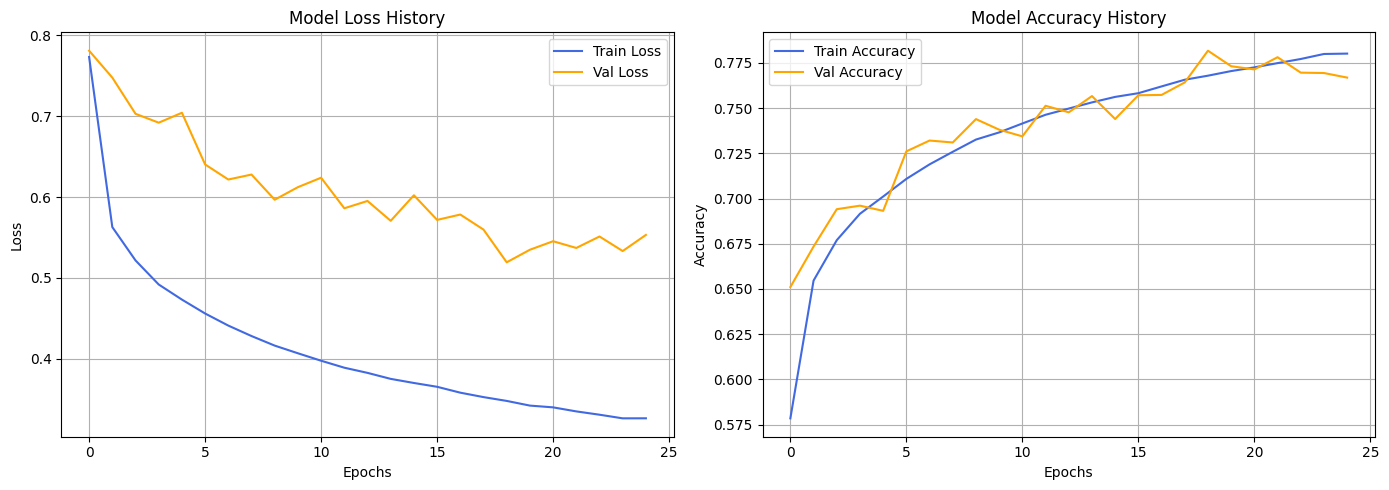

Evaluating model on test dataset...

Classification Report:

              precision    recall  f1-score   support

     Class 1       0.75      0.83      0.79     21184
     Class 2       0.88      0.68      0.77     28331
     Class 3       0.80      0.79      0.80      3576
     Class 4       0.64      0.95      0.77       274
     Class 5       0.30      0.96      0.46       949
     Class 6       0.50      0.91      0.64      1737
     Class 7       0.71      0.96      0.82      2051

    accuracy                           0.77     58102
   macro avg       0.66      0.87      0.72     58102
weighted avg       0.80      0.77      0.77     58102



In [3]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

# 1. Train the model with class weights
print("Training the model...")
history = model.fit(
    X_train, y_train,
    epochs=25,
    batch_size=512,
    validation_data=(X_val, y_val),
    class_weight=class_weights_dict,
    verbose=1
)

# 2. Plot the training & validation loss and accuracy curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss Curve
ax1.plot(history.history['loss'], label='Train Loss', color='royalblue')
ax1.plot(history.history['val_loss'], label='Val Loss', color='orange')
ax1.set_title('Model Loss History')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

# Accuracy Curve
ax2.plot(history.history['accuracy'], label='Train Accuracy', color='royalblue')
ax2.plot(history.history['val_accuracy'], label='Val Accuracy', color='orange')
ax2.set_title('Model Accuracy History')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

# 3. Evaluate the model on test set
print("Evaluating model on test dataset...")
y_pred_prob = model.predict(X_test, batch_size=512, verbose=0)
y_pred = np.argmax(y_pred_prob, axis=1)

# 4. Comprehensive classification report
target_names = [f"Class {i+1}" for i in range(7)]
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=target_names))

Classification Report:

              precision    recall  f1-score   support

     Class 1       0.75      0.83      0.79     21184
     Class 2       0.88      0.68      0.77     28331
     Class 3       0.80      0.79      0.80      3576
     Class 4       0.64      0.95      0.77       274
     Class 5       0.30      0.96      0.46       949
     Class 6       0.50      0.91      0.64      1737
     Class 7       0.71      0.96      0.82      2051

    accuracy                           0.77     58102
   macro avg       0.66      0.87      0.72     58102
weighted avg       0.80      0.77      0.77     58102



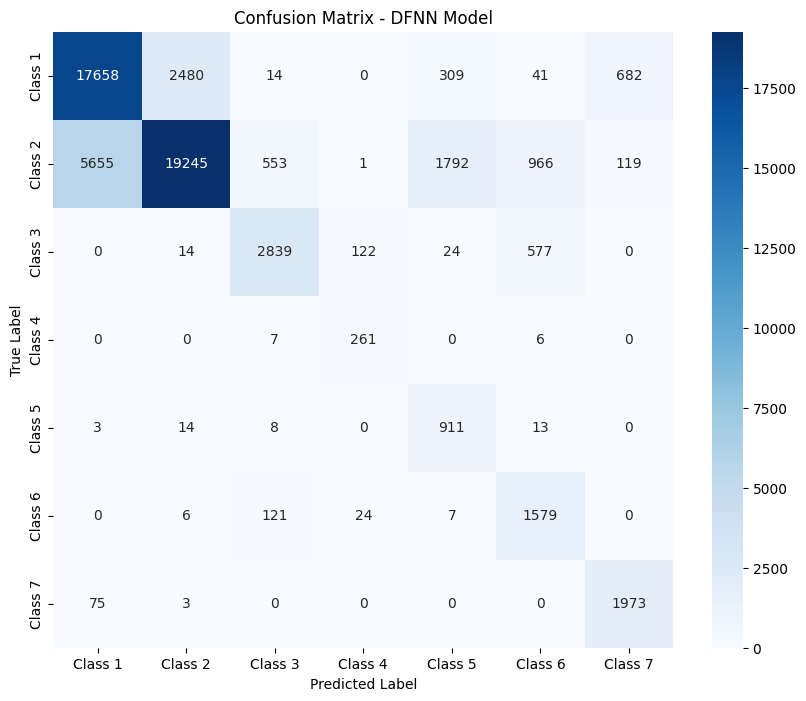

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# Calculate predictions and print classification report again to verify
y_pred_prob = model.predict(X_test, batch_size=512, verbose=0)
y_pred = np.argmax(y_pred_prob, axis=1)

target_names = [f'Class {i+1}' for i in range(7)]
print('Classification Report:\n')
print(classification_report(y_test, y_pred, target_names=target_names))

# Generate and plot confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix - DFNN Model')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()